# House Pricing Calculation

En este notebook, revisaremos el código del compañero de codificación para Intuitive Deep Learning Parte 1 ([Parte 1a](https://medium.com/intuitive-deep-learning/intuitive-deep-learning-part-1a-introduction-to-neural-networks-d7b16ebf6b99), [Parte 1b](https://medium.com/intuitive-deep-learning/intuitive-deep-learning-part-1b-introduction-to-neural-networks-8565d97ddd2d)) para crear tu primera red neuronal para predecir si el precio de una casa está por debajo o por encima del valor mediano. Recorreremos lo siguiente en este notebook:

- Exploración y Procesamiento de Datos
- Construcción y Entrenamiento de Nuestra Red Neuronal
- Visualización de Pérdida y Precisión
- Añadiendo Regularización a Nuestra Red Neuronal

El código está anotado a lo largo del notebook y simplemente necesitas descargar el conjunto de datos [aquí](https://drive.google.com/file/d/1GfvKA0qznNVknghV4botnNxyH-KvODOC/view), colocar el conjunto de datos en la misma carpeta que este notebook y ejecutar las celdas de código a continuación. Ten en cuenta que los resultados que obtengas pueden diferir ligeramente de la publicación del blog, ya que existe un cierto grado de aleatoriedad en la forma en que dividimos nuestro conjunto de datos, así como en la inicialización de nuestra red neuronal.

## Carga los datos utilizados para entrenar tu modelo.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving housepricedata.csv to housepricedata (1).csv


# Exploración y Procesamiento de Datos

Primero tenemos que leer el archivo CSV que se nos ha proporcionado. Para ello utilizaremos un paquete llamado `pandas`:

In [41]:
import pandas as pd

In [42]:
df = pd.read_csv('housepricedata.csv')

In [43]:
df

,LotArea,OverallQual,OverallCond,TotalBsmtSF,FullBath,HalfBath,BedroomAbvGr,TotRmsAbvGrd,Fireplaces,GarageArea,AboveMedianPrice
0,8450,7,5,856,2,1,3,8,0,548,1
1,9600,6,8,1262,2,0,3,6,1,460,1
2,11250,7,5,920,2,1,3,6,1,608,1
3,9550,7,5,756,1,0,3,7,1,642,0
4,14260,8,5,1145,2,1,4,9,1,836,1
...,...,...,...,...,...,...,...,...,...,...,...
1455,7917,6,5,953,2,1,3,7,1,460,1
1456,13175,6,6,1542,2,0,3,7,2,500,1
1457,9042,7,9,1152,2,0,4,9,2,252,1
1458,9717,5,6,1078,1,0,2,5,0,240,0


El conjunto de datos que tenemos ahora está en lo que llamamos un `dataframe` de pandas. Para convertirlo en un `array`, simplemente accede a sus valores:

In [44]:
dataset = df.values

In [45]:
dataset

array([[ 8450,     7,     5, ...,     0,   548,     1],
       [ 9600,     6,     8, ...,     1,   460,     1],
       [11250,     7,     5, ...,     1,   608,     1],
       ...,
       [ 9042,     7,     9, ...,     2,   252,     1],
       [ 9717,     5,     6, ...,     0,   240,     0],
       [ 9937,     5,     6, ...,     0,   276,     0]])

Ahora, dividimos el conjunto de datos en nuestras características de entrada y la etiqueta que deseamos predecir.

In [46]:
X = dataset[:,0:10]
Y = dataset[:,10]

Normalizar nuestros datos es muy importante, ya que queremos que las características de entrada estén en el mismo orden de magnitud para facilitar nuestro entrenamiento. Usaremos un escalador min-max de scikit-learn que escala nuestros datos para que estén entre 0 y 1.

In [47]:
from sklearn import preprocessing

In [48]:
min_max_scaler = preprocessing.MinMaxScaler()
X_scale = min_max_scaler.fit_transform(X)

In [49]:
X_scale

array([[0.0334198 , 0.66666667, 0.5       , ..., 0.5       , 0.        ,
        0.3864598 ],
       [0.03879502, 0.55555556, 0.875     , ..., 0.33333333, 0.33333333,
        0.32440056],
       [0.04650728, 0.66666667, 0.5       , ..., 0.33333333, 0.33333333,
        0.42877292],
       ...,
       [0.03618687, 0.66666667, 1.        , ..., 0.58333333, 0.66666667,
        0.17771509],
       [0.03934189, 0.44444444, 0.625     , ..., 0.25      , 0.        ,
        0.16925247],
       [0.04037019, 0.44444444, 0.625     , ..., 0.33333333, 0.        ,
        0.19464034]])

Por último, deseamos reservar algunas partes de nuestro conjunto de datos para un conjunto de validación y un conjunto de prueba. Usamos la función `train_test_split` de scikit-learn para hacer eso.

In [50]:
from sklearn.model_selection import train_test_split

In [51]:
X_train, X_val_and_test, Y_train, Y_val_and_test = train_test_split(X_scale, Y, test_size=0.3)

In [52]:
X_val, X_test, Y_val, Y_test = train_test_split(X_val_and_test, Y_val_and_test, test_size=0.5)

In [53]:
print(X_train.shape, X_val.shape, X_test.shape, Y_train.shape, Y_val.shape, Y_test.shape)

(1022, 10) (219, 10) (219, 10) (1022,) (219,) (219,)


# Construyendo y Entrenando Nuestra Primera Red Neuronal

Usaremos Keras para construir nuestra arquitectura. Importemos el código de Keras que necesitaremos usar:

### Resumen de la Arquitectura de la Red Neuronal

Vamos a visualizar la arquitectura de nuestra primera red neuronal usando `model.summary()`. Esto nos mostrará las capas, las formas de salida y el número de parámetros en cada capa.

In [78]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 32)             │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,443 (5.64 KB)

 Trainable params: 1,441 (5.63 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [54]:
from keras.models import Sequential
from keras.layers import Dense

Usaremos el modelo `Sequential`, lo que significa que simplemente necesitamos describir las capas anteriores en secuencia. Nuestra red neuronal tiene tres capas:

- Capa oculta 1: 30 neuronas, activación ReLU
- Capa oculta 2: 30 neuronas, activación ReLU
- Capa de salida: 1 neurona, activación Sigmoid

In [55]:
model = Sequential([
    Dense(32, activation='relu', input_shape=(10,)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid'),
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Ahora que hemos especificado nuestra arquitectura, necesitamos encontrar los mejores números para ella. Antes de comenzar nuestro entrenamiento, tenemos que configurar el modelo por:
- Indicarle qué algoritmo quieres usar para hacer la optimización (usaremos descenso de gradiente estocástico)
- Indicarle qué función de pérdida usar (para clasificación binaria, usaremos entropía cruzada binaria)
- Indicarle qué otras métricas quieres seguir además de la función de pérdida (también queremos seguir la precisión)

Hacemos esto a continuación:

In [56]:
model.compile(optimizer='sgd',
              loss='binary_crossentropy',
              metrics=['accuracy'])

Entrenar con los datos es bastante sencillo y requiere que escribamos una línea de código. La función se llama 'fit' ya que estamos ajustando los parámetros a los datos. Especificamos:
- los datos con los que estamos entrenando, que son X_train e Y_train
- el tamaño de nuestro mini-lote
- cuánto tiempo queremos entrenarlo (épocas)
- cuáles son nuestros datos de validación para que el modelo nos diga cómo nos está yendo con los datos de validación en cada punto.

Esta función producirá un historial, que guardamos bajo la variable `hist`. Usaremos esta variable un poco más tarde.

In [57]:
hist = model.fit(X_train, Y_train,
          batch_size=32, epochs=100,
          validation_data=(X_val, Y_val))

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5020 - loss: 0.6972 - val_accuracy: 0.4795 - val_loss: 0.6947
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5039 - loss: 0.6904 - val_accuracy: 0.5708 - val_loss: 0.6876
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6389 - loss: 0.6854 - val_accuracy: 0.6484 - val_loss: 0.6822
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6703 - loss: 0.6813 - val_accuracy: 0.6895 - val_loss: 0.6775
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7211 - loss: 0.6776 - val_accuracy: 0.7626 - val_loss: 0.6732
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7573 - loss: 0.6741 - val_accuracy: 0.8037 - val_loss: 0.6691
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7593 - loss: 0.6706 - val_accuracy: 0.8037 - val_loss: 0.6651
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7671 - loss: 0.6671 - val_accuracy: 0.8082 - 

Evaluando nuestros datos en el conjunto de prueba:

In [58]:
model.evaluate(X_test, Y_test)[1]

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9041 - loss: 0.2923 


0.9041095972061157

# Visualizando Pérdida y Precisión

Importamos el paquete relevante que necesitamos para la visualización

In [59]:
import matplotlib.pyplot as plt

Queremos visualizar la pérdida de entrenamiento y la pérdida de validación de esta manera:

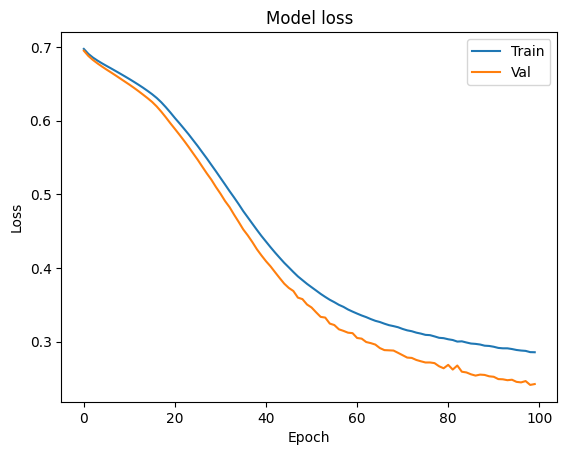

In [60]:
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper right')
plt.show()

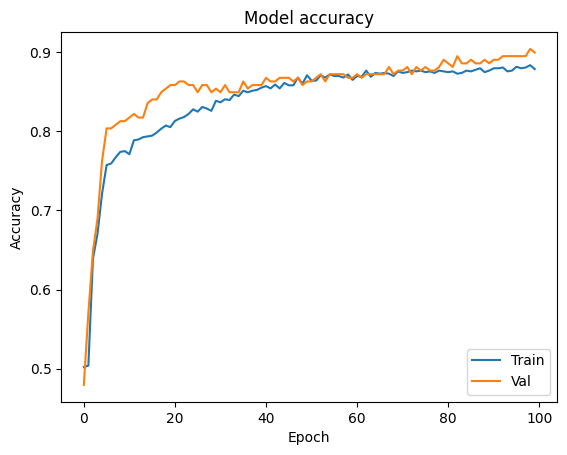

In [61]:
plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='lower right')
plt.show()

### Demostración de Predicción con el Modelo Entrenado

Ahora, veamos cómo nuestro `modelo` entrenado (el primer modelo que construimos) realiza una predicción sobre un nuevo punto de datos hipotético.

El array `new_house_features` representa una única casa hipotética con 10 características, en el siguiente orden:

1.  **LotArea**: Superficie del lote en pies cuadrados.
2.  **OverallQual**: Calidad general del material y acabado (1-10).
3.  **OverallCond**: Calificación general de la condición (1-9).
4.  **TotalBsmtSF**: Metros cuadrados totales del sótano.
5.  **FullBath**: Número de baños completos sobre el nivel del suelo.
6.  **HalfBath**: Número de medios baños sobre el nivel del suelo.
7.  **BedroomAbvGr**: Número de dormitorios sobre el nivel del suelo (no incluye dormitorios en el sótano).
8.  **TotRmsAbvGrd**: Total de habitaciones sobre el nivel del suelo (no incluye baños).
9.  **Fireplaces**: Número de chimeneas.
10. **GarageArea**: Tamaño del garaje en pies cuadrados.

In [ ]:
# Create a new data point for prediction (hypothetical example)
# Ensure features are in the same order as the original training set (X)
# and are within the unscaled value ranges.
# The 10 features are: LotArea, OverallQual, OverallCond, TotalBsmtSF, FullBath, HalfBath, BedroomAbvGr, TotRmsAbvGrd, Fireplaces, GarageArea

new_house_features = [[8500, 7, 6, 900, 2, 1, 3, 7, 1, 500]] # An example house

# Convert to numpy array and scale using the same MinMaxScaler used for X_scale
import numpy as np
new_house_features_scaled = min_max_scaler.transform(np.array(new_house_features))

print("New house features (scaled):")
print(new_house_features_scaled)

# Perform the prediction with the 'model' (the first trained model)
prediction = model.predict(new_house_features_scaled)

print(f"\nPredicted probability that the price is above the median: {prediction[0][0]:.4f}")

# Interpret the prediction
if prediction[0][0] >= 0.5:
    print("The model predicts that the price of this house will be above the median value.")
else:
    print("The model predicts that the price of this house will be below the median value.")

The `new_house_features` array represents a single hypothetical house with 10 features, in the following order:

1.  **LotArea**: Lot size in square feet.
2.  **OverallQual**: Overall material and finish quality (1-10).
3.  **OverallCond**: Overall condition rating (1-9).
4.  **TotalBsmtSF**: Total square feet of basement area.
5.  **FullBath**: Number of full bathrooms above grade.
6.  **HalfBath**: Number of half baths above grade.
7.  **BedroomAbvGr**: Number of bedrooms above grade (does not include basement bedrooms).
8.  **TotRmsAbvGrd**: Total rooms above grade (does not include bathrooms).
9.  **Fireplaces**: Number of fireplaces.
10. **GarageArea**: Size of garage in square feet.

In [63]:
# Create a new data point for prediction (hypothetical example)
# Ensure features are in the same order as the original training set (X)
# and are within the unscaled value ranges.
# The 10 features are: LotArea, OverallQual, OverallCond, TotalBsmtSF, FullBath, HalfBath, BedroomAbvGr, TotRmsAbvGrd, Fireplaces, GarageArea

new_house_features = [[8500, 7, 6, 900, 2, 1, 3, 7, 1, 500]] # An example house

# Convert to numpy array and scale using the same MinMaxScaler used for X_scale
import numpy as np
new_house_features_scaled = min_max_scaler.transform(np.array(new_house_features))

print("New house features (scaled):")
print(new_house_features_scaled)

# Perform the prediction with the 'model' (the first trained model)
prediction = model.predict(new_house_features_scaled)

print(f"\nPredicted probability that the price is above the median: {prediction[0][0]:.4f}")

# Interpret the prediction
if prediction[0][0] >= 0.5:
    print("The model predicts that the price of this house will be above the median value.")
else:
    print("The model predicts that the price of this house will be below the median value.")

New house features (scaled):
[[0.03365351 0.66666667 0.625      0.14729951 0.66666667 0.5
  0.375      0.41666667 0.33333333 0.35260931]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step

Predicted probability that the price is above the median: 0.9283
The model predicts that the price of this house will be above the median value.


# Añadiendo Regularización a Nuestra Red Neuronal

Entrenaremos un modelo que se sobreajustará, al que llamaremos Modelo 2. Esto puede tardar unos minutos.

In [64]:
model_2 = Sequential([
    Dense(1000, activation='relu', input_shape=(10,)),
    Dense(1000, activation='relu'),
    Dense(1000, activation='relu'),
    Dense(1000, activation='relu'),
    Dense(1, activation='sigmoid'),
])
model_2.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])
hist_2 = model_2.fit(X_train, Y_train,
          batch_size=32, epochs=100,
          validation_data=(X_val, Y_val))

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - accuracy: 0.7603 - loss: 0.5131 - val_accuracy: 0.8265 - val_loss: 0.3543
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - accuracy: 0.8523 - loss: 0.3686 - val_accuracy: 0.8858 - val_loss: 0.3058
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - accuracy: 0.8620 - loss: 0.3262 - val_accuracy: 0.8950 - val_loss: 0.2539
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.8699 - loss: 0.3138 - val_accuracy: 0.9087 - val_loss: 0.2089
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.8836 - loss: 0.2848 - val_accuracy: 0.8767 - val_loss: 0.2277
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.8894 - loss: 0.2723 - val_accuracy: 0.8995 - val_loss: 0.2212
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.8836 - loss: 0.2889 - val_accuracy: 0.9315 - val_loss: 0.1826
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.8836 - loss: 0.2656 - val_accuracy: 0.9224 - val_l

Hagamos la misma visualización para ver cómo se ve el sobreajuste en términos de pérdida y precisión.

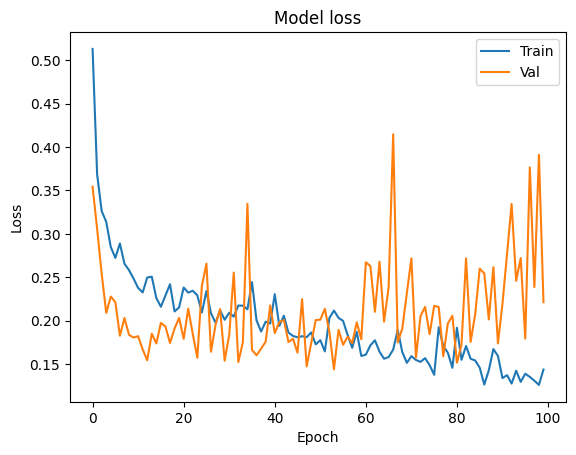

In [66]:
plt.plot(hist_2.history['loss'])
plt.plot(hist_2.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper right')
plt.show()

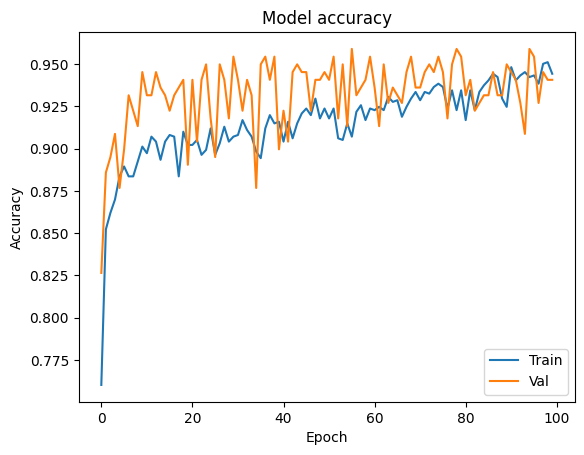

In [67]:
plt.plot(hist_2.history['accuracy'])
plt.plot(hist_2.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='lower right')
plt.show()

Para abordar el sobreajuste que vemos en el Modelo 2, incorporaremos regularización L2 y dropout en nuestro tercer modelo aquí (Modelo 3).

In [80]:
from keras.layers import Dropout
from keras import regularizers

In [81]:
model_3 = Sequential([
    Dense(1000, activation='relu', kernel_regularizer=regularizers.l2(0.01), input_shape=(10,)),
    Dropout(0.3),
    Dense(1000, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    Dropout(0.3),
    Dense(1000, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    Dropout(0.3),
    Dense(1000, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    Dropout(0.3),
    Dense(1, activation='sigmoid', kernel_regularizer=regularizers.l2(0.01)),
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [82]:
model_3.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])
hist_3 = model_3.fit(X_train, Y_train,
          batch_size=32, epochs=100,
          validation_data=(X_val, Y_val))

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - accuracy: 0.6360 - loss: 14.2690 - val_accuracy: 0.8311 - val_loss: 3.9473
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.7847 - loss: 1.7155 - val_accuracy: 0.8721 - val_loss: 0.6391
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - accuracy: 0.8376 - loss: 0.5874 - val_accuracy: 0.8584 - val_loss: 0.5490
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 107ms/step - accuracy: 0.8620 - loss: 0.5177 - val_accuracy: 0.8858 - val_loss: 0.4569
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.8689 - loss: 0.4879 - val_accuracy: 0.8904 - val_loss: 0.4295
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - accuracy: 0.8659 - loss: 0.4865 - val_accuracy: 0.8904 - val_loss: 0.4404
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 108ms/step - accuracy: 0.8571 - loss: 0.4906 - val_accuracy: 0.8904 - val_loss: 0.4296
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 98ms/step - accuracy: 0.8748 - loss: 0.4769 - val_accuracy:

Ahora trazaremos los gráficos de pérdida y precisión para el Modelo 3. Notarás que la pérdida es mucho mayor al principio, y esto se debe a que hemos cambiado nuestra función de pérdida. Para graficar de modo que la ventana se amplíe entre 0 y 1.2 para la pérdida, agregamos una línea de código adicional (`plt.ylim`) al graficar.

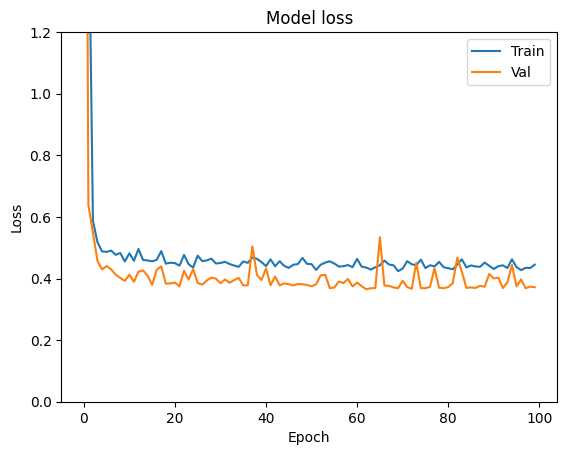

In [83]:
plt.plot(hist_3.history['loss'])
plt.plot(hist_3.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper right')
plt.ylim(top=1.2, bottom=0)
plt.show()

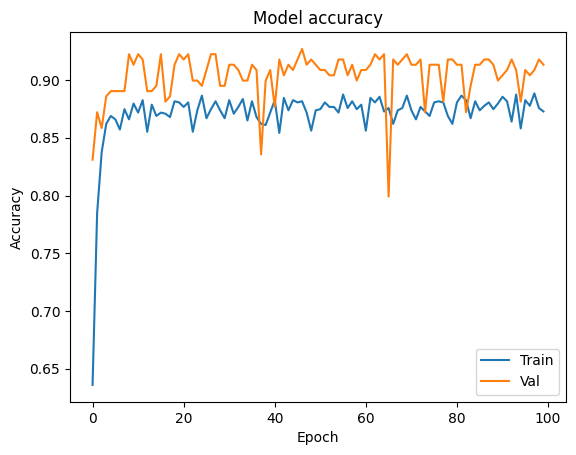

In [84]:
plt.plot(hist_3.history['accuracy'])
plt.plot(hist_3.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='lower right')
plt.show()

En comparación con el Modelo 2, ¡deberías ver que hay menos sobreajuste!

### ¿Por qué hay Overfitting en el Modelo 2?

El **overfitting** (sobreajuste) se produce cuando un modelo de aprendizaje automático aprende los datos de entrenamiento con demasiado detalle, incluyendo el ruido y las particularidades específicas de esos datos, en lugar de aprender los patrones generales que son aplicables a nuevos datos.

En el **Modelo 2**, observamos overfitting por varias razones, que se hacen evidentes al comparar las curvas de entrenamiento y validación en las gráficas de pérdida y precisión:

1.  **Complejidad del Modelo**: El Modelo 2 utiliza cuatro capas ocultas, cada una con 1000 neuronas (`Dense(1000)`). Un modelo con una gran cantidad de parámetros (neuronas y capas) tiene una capacidad muy alta para memorizar los datos de entrenamiento.
2.  **Falta de Regularización**: A diferencia del Modelo 3, el Modelo 2 no incluye técnicas de regularización como L2 (regularización de peso) o Dropout. Estas técnicas están diseñadas específicamente para evitar el overfitting al penalizar pesos grandes o desactivar neuronas aleatoriamente durante el entrenamiento.
3.  **Número de Épocas**: El modelo fue entrenado durante 100 épocas. Sin regularización, entrenar un modelo complejo durante muchas épocas le da amplias oportunidades para "memorizar" los datos de entrenamiento.

**¿Cómo se ve el Overfitting en las Gráficas?**

*   **Pérdida (Loss)**: La `pérdida de entrenamiento` (línea azul) continúa disminuyendo, a menudo acercándose a cero, mientras que la `pérdida de validación` (línea naranja) deja de disminuir en algún punto y comienza a aumentar. Esto indica que el modelo está mejorando en los datos que ha visto, pero empeorando en los datos nuevos y no vistos.
*   **Precisión (Accuracy)**: La `precisión de entrenamiento` (línea azul) sigue aumentando, a menudo acercándose al 100%, mientras que la `precisión de validación` (línea naranja) se estanca o incluso disminuye después de alcanzar un pico. Esto significa que el modelo está aprendiendo las respuestas correctas para los datos de entrenamiento, pero no está generalizando bien a los datos de validación.

En resumen, la combinación de un modelo muy complejo y la ausencia de técnicas para forzarlo a generalizar (regularización) llevó a que el Modelo 2 se sobreajustara a los datos de entrenamiento.